In [2]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt

$$dx^i=A^i(x,\tau)d\tau+B^i_a(x,\tau)dW^a$$

$$i=1,...,var dim$$
$$a=1,..,noise dim$$

In [3]:
class Ito_equation:
    def __init__(self,var_dim=1,noise_dim=1):

        self.var_dim = var_dim
        self.noise_dim = noise_dim

    def A(self,x):
        pass 

    def B(self,x):
        pass    


In [4]:
class Scheme:
    def __init__(self,equation,time_step,**params):
        
        self.time_step = time_step
        self.eq = equation

    def one_iteration(self,x):
        pass  


class Euler(Scheme):
    
    def __init__(self,equation,time_step):
        super().__init__(equation,time_step)     

    def epsilon(self):
        return normal(0,1,self.eq.noise_dim)


    def one_iteration(self,x):
        x += self.eq.A(x) * self.time_step + np.dot(self.eq.B(x),self.epsilon()) * (self.time_step) ** 0.5       

    

In [5]:
class Ito_solver:
    def __init__(self,equation,scheme,time_step,total_time,N_samples):


        self.eq = equation
        self.scheme = scheme(equation,time_step)
        
        self.total_time = total_time
        self.time_step = time_step

        self.tau_grid = np.arange(0,self.total_time,self.time_step)
         

        self.N_steps = int(total_time//time_step)
        self.N_samples = N_samples

        self.x = np.zeros(self.eq.var_dim)
        self.result = np.zeros((self.N_samples, self.N_steps + 1 , self.eq.var_dim))
        
    
    
    def solve_one_process(self,initial_cond):

        traj = np.zeros((self.N_steps+1 , self.eq.var_dim)) 

        self.x = np.copy(initial_cond)
        traj[0,:] = np.copy(initial_cond)
        
        for k in range(1,self.N_steps+1):
            self.scheme.one_iteration(self.x)
            traj[k,:] = np.copy(self.x)

        return traj 

    
    def solve(self,initial_cond):
        for i in range(self.N_samples):
            self.result[i,:,:] =  self.solve_one_process(initial_cond)

    


In [6]:
class Quadratic_gravity(Ito_equation):
    def __init__(self,sigma,nu):
        super().__init__(3,1)
        self.sigma = sigma
        self.nu = nu
    
    def A(self,x):
        a_beta = x[0] ** 2 - self.nu * x[1] ** 2
        a_alpha = x[0] * x[1]
        a_g = x[1]
        return np.array([a_beta,a_alpha,a_g])
    
    def B(self,x):
        b_arr = np.zeros((3,1))
        b_arr[0][0] = self.sigma 
        return b_arr 

            

In [7]:
qg = Quadratic_gravity(0,1)
qg_solver = Ito_solver(qg,Euler,0.0001,1,1) 

In [8]:
qg_solver.solve(np.array([1.0,1.0,0.0]))

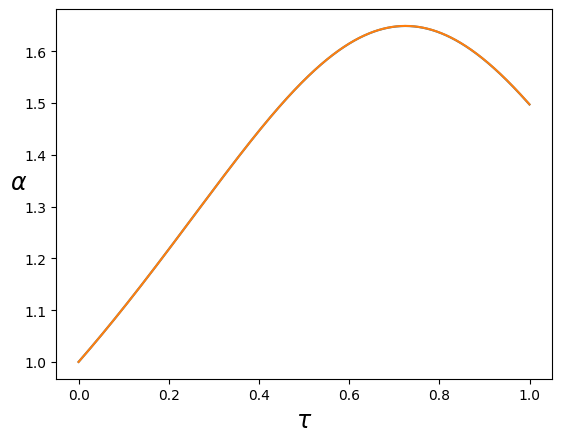

In [9]:
plt.figure()
g = qg_solver.result[0,:,2]
alpha = qg_solver.result[0,:,1]
beta = qg_solver.result[0,:,0] 
plt.plot(qg_solver.tau_grid,np.exp(g-1/2 * g**2))
plt.plot(qg_solver.tau_grid,alpha)
plt.xlabel(r'$\tau$',fontsize=17)
plt.ylabel(r'$\alpha$',fontsize=17,rotation=0)    
plt.show()

In [77]:
np.save("g",g)
np.save("alpha",alpha)
np.save("tau_grid",qg_solver.tau_grid)

In [ ]:
"""
class Ornstein_Ulenbek(Ito_equation):
    def __init__(self,alpha,beta,sigma):
        self.alpha = alpha
        self.beta = beta 
        self.sigma = sigma 
        
        super().__init__(1,1)

    def A(self,x):
        a_arr = np.zeros((1)) 
        a_arr = -self.beta * (x-self.alpha)
        return a_arr
    def B(self,x):
        b_arr = np.zeros((1,1))
        b_arr[0][0] = self.sigma
        return b_arr
"""        

''

In [76]:
orn = Ornstein_Ulenbek(0,1,1)
orn_solver = Ito_solver(orn,Euler,0.0001,10,10)
    

In [77]:
orn_solver.solve(np.array([1.0]))


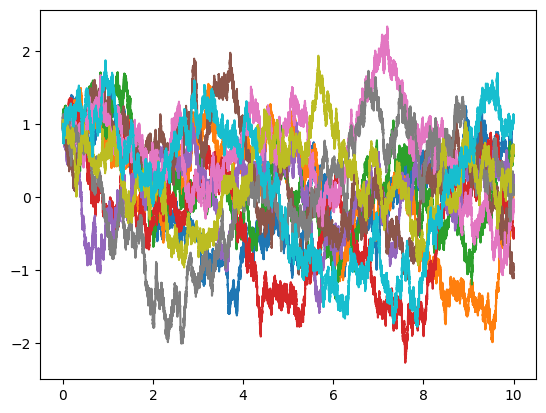

In [78]:
plt.figure()
for s in range(orn_solver.N_samples):
    plt.plot(orn_solver.time_grid,orn_solver.result[s,:,0])
plt.show()